# Instagram Engagement Analysis
### InternSpark Internship - Task 3

**Objective:**
Analyze Instagram user engagement to identify the best posting times, high-performing content types, hashtag usage, and follower growth signals using Python, Pandas, and Matplotlib.

## Importing Required Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Loading the Datasets

In [32]:
users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
photo_tags = pd.read_csv("photo_tags.csv")
tags = pd.read_csv("tags.csv")
follows = pd.read_csv("follows.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


## Data Understanding

In [33]:
print("Users Dataset")
display(users.head())

print("Photos Dataset")
display(photos.head())

print("Likes Dataset")
display(likes.head())

print("Comments Dataset")
display(comments.head())

Users Dataset


,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


Photos Dataset


,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


Likes Dataset


,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


Comments Dataset


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [34]:
print("Users Dataset Information")
users.info()

print("\nPhotos Dataset Information")
photos.info()

print("\nLikes Dataset Information")
likes.info()

print("\nComments Dataset Information")
comments.info()

print("\nTags Dataset Information")
tags.info()

Users Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB

Photos Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 257 non-null    int64 
 1   image link         257 non-null    object
 2   user ID            257 non-null    int64 
 3   created dat        257 non-null    object
 4   Insta filter used  257 non-null    object


In [35]:
print("Users Shape:", users.shape)
print("Photos Shape:", photos.shape)
print("Likes Shape:", likes.shape)
print("Comments Shape:", comments.shape)
print("Tags Shape:", tags.shape)
print("Follows Shape:", follows.shape)

Users Shape: (100, 6)
Photos Shape: (257, 6)
Likes Shape: (8782, 5)
Comments Shape: (7488, 8)
Tags Shape: (21, 4)
Follows Shape: (7623, 5)


In [36]:
## Data Cleaning

In [37]:
print("Users Missing Values")
print(users.isnull().sum())

print("\nPhotos Missing Values")
print(photos.isnull().sum())

print("\nLikes Missing Values")
print(likes.isnull().sum())

print("\nComments Missing Values")
print(comments.isnull().sum())

print("\nTags Missing Values")
print(tags.isnull().sum())

print("\nFollows Missing Values")
print(follows.isnull().sum())

Users Missing Values
id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64

Photos Missing Values
id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64

Likes Missing Values
user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64

Comments Missing Values
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64

Tags Missing Values
id              0
tag text        0
created time    0
location        0
dtype: int64

Follows Missing Values
follower               0
followee               0
created time           0
is follower active     0
followee Acc status    0
dtype: int64


In [38]:
print("Users Duplicates:", users.duplicated().sum())
print("Photos Duplicates:", photos.duplicated().sum())
print("Likes Duplicates:", likes.duplicated().sum())
print("Comments Duplicates:", comments.duplicated().sum())
print("Tags Duplicates:", tags.duplicated().sum())
print("Follows Duplicates:", follows.duplicated().sum())

Users Duplicates: 0
Photos Duplicates: 0
Likes Duplicates: 0
Comments Duplicates: 0
Tags Duplicates: 0
Follows Duplicates: 0


## Engagement Analysis

In [39]:
print("Likes Columns:")
print(likes.columns)

print("\nComments Columns:")
print(comments.columns)

print("\nPhotos Columns:")
print(photos.columns)

Likes Columns:
Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='object')

Comments Columns:
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')

Photos Columns:
Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')


In [40]:
likes_count = likes.groupby('photo').size().reset_index(name='total_likes')

likes_count.head()

,photo,total_likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


In [41]:
comments_count = comments.groupby('Photo id').size().reset_index(name='total_comments')

comments_count.head()

,Photo id,total_comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


In [42]:
engagement = photos.merge(
    likes_count,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_count,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement.fillna(0, inplace=True)

engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,total_likes,Photo id,total_comments
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27


In [43]:
engagement['total_engagement'] = (
    engagement['total_likes'] + engagement['total_comments']
)

engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,total_likes,Photo id,total_comments,total_engagement
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


In [44]:
top_posts = engagement.sort_values(
    by='total_engagement',
    ascending=False
)

top_posts.head(10)

,id,image link,user ID,created dat,Insta filter used,photo type,photo,total_likes,Photo id,total_comments,total_engagement
12,13,https://fred.com,3,13-04-2023 08:04,no,photo,13,40,13,39,79
144,145,https://jarret.name,52,13-04-2023 08:04,yes,video,145,48,145,27,75
146,147,https://adela.com,55,13-04-2023 08:04,no,photo,147,41,147,34,75
117,118,http://whitney.net,43,13-04-2023 08:04,yes,photo,118,39,118,35,74
226,227,http://nigel.biz,87,13-04-2023 08:04,no,photo,227,39,227,35,74
195,196,http://stan.biz,73,13-04-2023 08:04,yes,photo,196,38,196,35,73
224,225,https://celestino.name,87,13-04-2023 08:04,no,video,225,37,225,36,73
126,127,https://celestine.name,46,13-04-2023 08:04,yes,photo,127,43,127,30,73
122,123,http://shannon.org,44,13-04-2023 08:04,yes,photo,123,42,123,31,73
152,153,http://janie.com,58,13-04-2023 08:04,no,photo,153,40,153,32,72


## Top Performing Instagram Posts

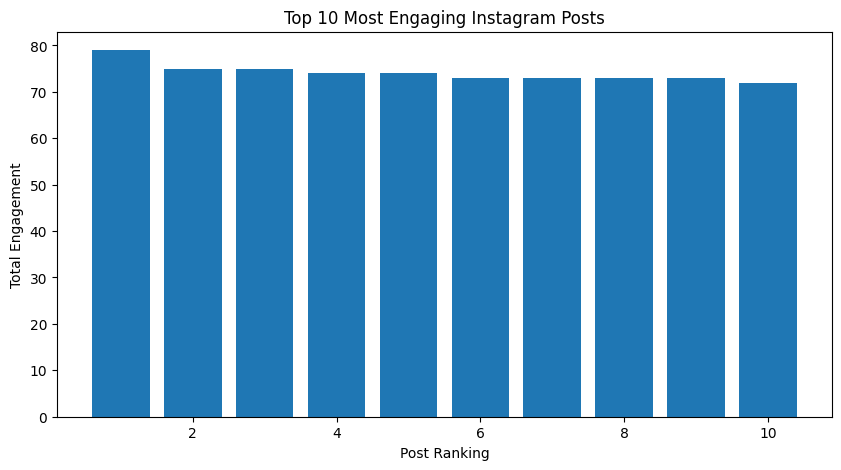

In [45]:
plt.figure(figsize=(10,5))

plt.bar(
    range(1,11),
    top_posts['total_engagement'].head(10)
)

plt.title("Top 10 Most Engaging Instagram Posts")
plt.xlabel("Post Ranking")
plt.ylabel("Total Engagement")

plt.show()

## Hashtag Performance Analysis

In [46]:
top_hashtags = tags['tag text'].value_counts().head(10)

top_hashtags

,count
tag text,
sunset,1
photography,1
sunrise,1
landscape,1
food,1
foodie,1
delicious,1
beauty,1
stunning,1


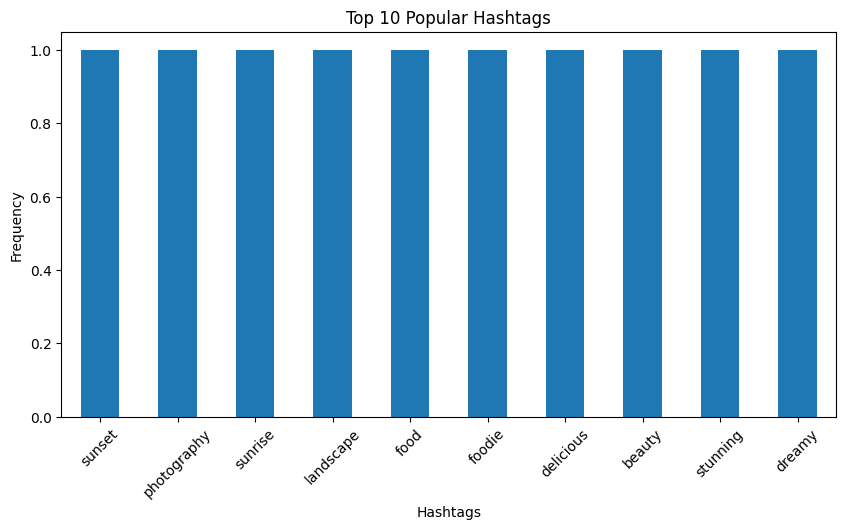

In [47]:
plt.figure(figsize=(10,5))

top_hashtags.plot(kind='bar')

plt.title("Top 10 Popular Hashtags")
plt.xlabel("Hashtags")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## Content Type Analysis

In [48]:
photo_type_count = photos['photo type'].value_counts()

photo_type_count

,count
photo type,
photo,155
video,52
carousel,50


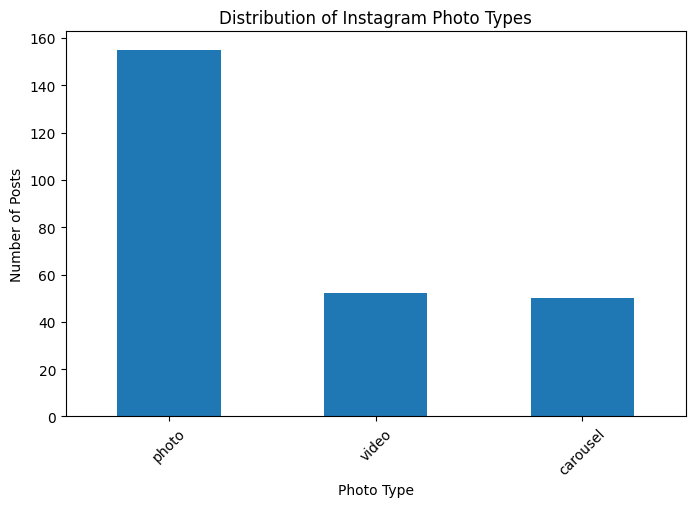

In [49]:
plt.figure(figsize=(8,5))

photo_type_count.plot(kind='bar')

plt.title("Distribution of Instagram Photo Types")
plt.xlabel("Photo Type")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.show()

In [50]:
photos['created dat'] = pd.to_datetime(photos['created dat'])

photos['hour'] = photos['created dat'].dt.hour

posting_time = photos['hour'].value_counts().sort_index()

posting_time

,count
hour,
8,257


## Best Posting Time Analysis

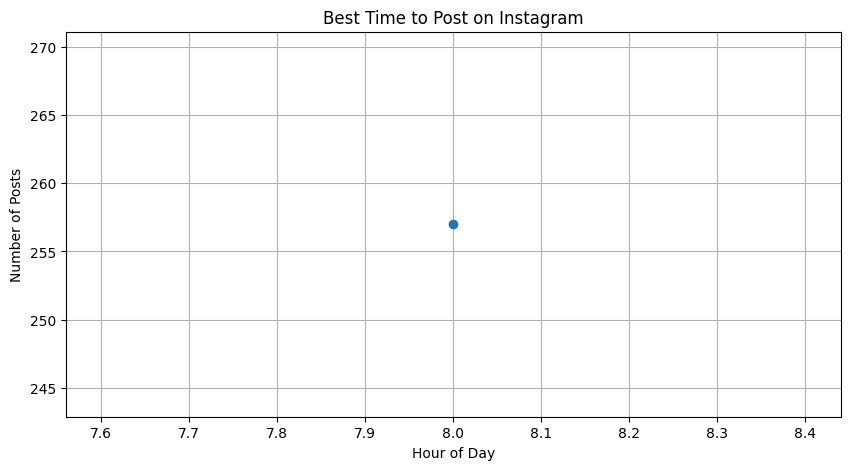

In [51]:
plt.figure(figsize=(10,5))

posting_time.plot(kind='line', marker='o')

plt.title("Best Time to Post on Instagram")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Posts")

plt.grid()

plt.show()

In [52]:
print(follows.columns)

Index(['follower', 'followee ', 'created time', 'is follower active',
       'followee Acc status'],
      dtype='object')


## Follower Growth Analysis

In [53]:
follower_count = follows.groupby('followee ').size().reset_index(name='followers')

follower_count = follower_count.sort_values(
    by='followers',
    ascending=False
)

follower_count.head(10)

,followee,followers
0,1,77
24,25,77
33,34,77
6,7,77
28,29,77
22,23,77
79,80,77
76,77,77
80,81,77
89,90,77


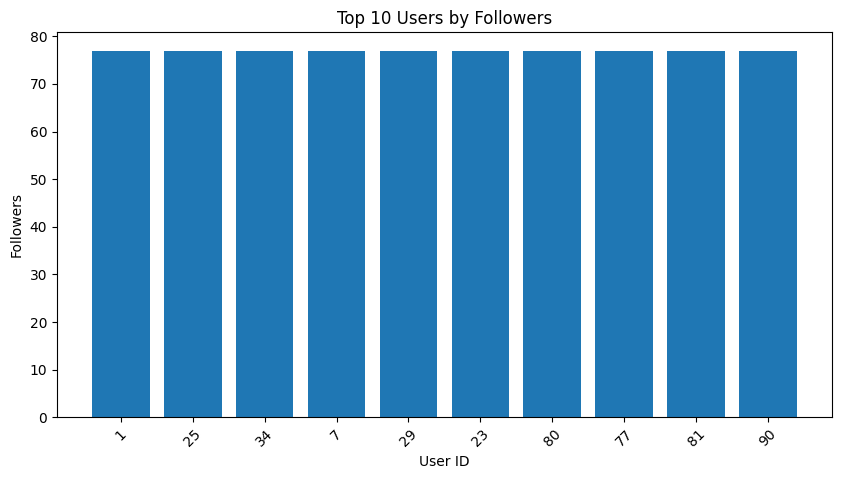

In [54]:
plt.figure(figsize=(10,5))

plt.bar(
    follower_count['followee '].head(10).astype(str),
    follower_count['followers'].head(10)
)

plt.title("Top 10 Users by Followers")
plt.xlabel("User ID")
plt.ylabel("Followers")

plt.xticks(rotation=45)

plt.show()

In [55]:
follows['is follower active'].value_counts()

,count
is follower active,
1,4197
0,3426


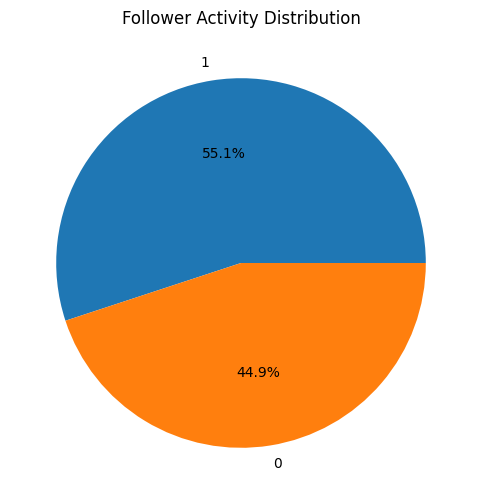

In [56]:
plt.figure(figsize=(6,6))

follows['is follower active'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Follower Activity Distribution")

plt.show()

# Conclusion

The analysis successfully identified user engagement patterns by examining likes, comments, hashtags, posting times, content types, and follower relationships.

Key findings include:

- Engagement varies significantly across posts.
- Certain hashtags appear more frequently than others.
- Photo type influences posting behavior.
- Posting activity is concentrated during specific hours of the day.
- Follower relationships provide insights into user popularity and network growth.

This analysis can help improve Instagram content strategy by identifying the best posting times and understanding engagement trends.